# HL-Gauss Compare Notebook
This notebook compares a baseline MSE regressor against an HL-Gauss regression-as-classification model.

## Setup
Imports, paths, artifact directories, and deterministic seeding.

In [1]:
"""HL-Gauss regression-as-classification vs baseline MSE."""

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

# Ensure src is on path for shared constants and helpers
ROOT = Path.cwd().parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

NOTEBOOK_DIR = Path.cwd()
ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "hl_gauss"
CHECKPOINT_DIR = ARTIFACT_ROOT / "checkpoints"
RESULTS_DIR = ARTIFACT_ROOT / "results"
PLOTS_DIR = ARTIFACT_ROOT / "plots"
CONFIG_SNAPSHOT_PATH = RESULTS_DIR / "config.json"
for _p in (ARTIFACT_ROOT, CHECKPOINT_DIR, RESULTS_DIR, PLOTS_DIR):
    _p.mkdir(parents=True, exist_ok=True)

from data.constants import CAT_COLS, LOG_COLS, NUMERIC_COLS, TARGET_COL
import data.encode_features as enc
from models.model import TabularRegressor
from models.train import TrainConfig, make_loaders, train_model

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# Overview
This notebook compares a baseline MSE tabular regressor against an HL-Gauss "regression as classification" approach that predicts a distribution over target bins and uses the expected value as the scalar prediction.

# Methodology
- Reuse the shared preprocessing pipeline via `enc.prepare_features(...)` and the shared training API in `src/models/train.py`.
- Load baseline artifacts to reuse hyperparameters, training history, and test metrics for plotting.
- Train HL-Gauss models with a small sweep over `(num_bins, sigma_ratio)` and select the best by validation MSE.
- Evaluate both models on the same test split with scalar predictions, then compare metrics and plots.

# HL-Gauss Target Distribution
Let `c_i` be bin centers and `y` the target. We clamp `y` to `[vmin, vmax]` and define:

```
    p_i proportional_to exp(-(c_i - y)^2 / (2 * sigma^2))
```

We normalize `p` to sum to 1 across bins. We set `sigma = sigma_ratio * bin_width`.

# HL-Gauss Loss and Prediction
We train using cross-entropy with soft labels:

```
    L = -sum_i p_i * log_softmax(logits)_i
```

At inference, the scalar prediction is the expectation over bins:

```
    y_hat = sum_i softmax(logits)_i * c_i
```

# Artifacts
Outputs are saved under `notebooks/artifacts/hl_gauss/`:
- `checkpoints/hl_gauss_regressor.pt`
- `results/training_history.csv`
- `results/test_metrics.csv`
- `results/sample_predictions.csv`
- `results/config.json`
- plots in `plots/`

## Baseline Artifacts
Load the baseline config, training history, and metrics for comparison plots.

In [2]:
BASELINE_ROOT = NOTEBOOK_DIR / "artifacts" / "baseline"
BASELINE_RESULTS = BASELINE_ROOT / "results"
BASELINE_CHECKPOINTS = BASELINE_ROOT / "checkpoints"

baseline_config_path = BASELINE_RESULTS / "config.json"
baseline_history_path = BASELINE_RESULTS / "training_history.csv"
baseline_metrics_path = BASELINE_RESULTS / "test_metrics.csv"
baseline_preds_path = BASELINE_RESULTS / "sample_predictions.csv"
baseline_model_path = BASELINE_CHECKPOINTS / "tabular_regressor.pt"

with baseline_config_path.open("r") as f:
    baseline_cfg = json.load(f)

baseline_history = pd.read_csv(baseline_history_path)
baseline_metrics = pd.read_csv(baseline_metrics_path)

print("Loaded baseline config keys:", sorted(baseline_cfg.keys()))
print("Baseline history shape:", baseline_history.shape)
print("Baseline metrics:")
print(baseline_metrics)

Loaded baseline config keys: ['artifact_root', 'batch_size', 'cat_dim', 'device', 'dropout', 'early_stop', 'encoder_hidden', 'epochs', 'freeze_encoder_epochs', 'head_hidden', 'input_dim', 'lr', 'mode', 'num_dim', 'scheduler', 'seed', 'weight_decay']
Baseline history shape: (53, 7)
Baseline metrics:
   test_mse  test_mae
0  1.041956  0.709799


## Data Preparation
Load train/val/test splits, run shared feature encoding, and build loaders.

In [3]:
data_dir = ROOT / "data" / "processed" / "all_features"

train_df = pd.read_csv(data_dir / "train.csv")
val_df = pd.read_csv(data_dir / "val.csv")
test_df = pd.read_csv(data_dir / "test.csv")

(
    X_train_np,
    X_val_np,
    X_test_np,
    y_train_np,
    y_val_np,
    y_test_np,
    artifacts,
) = enc.prepare_features(train_df, val_df, test_df)

input_dim = X_train_np.shape[1]
print(f"Input dim (shared): {input_dim}")
print(f"Train/val/test shapes: {X_train_np.shape}, {X_val_np.shape}, {X_test_np.shape}")

# Build loaders for shared (concatenated) features
batch_size = int(baseline_cfg.get("batch_size", 256))
train_loader, val_loader = make_loaders(
    X_train_np,
    y_train_np,
    X_val_np,
    y_val_np,
    batch_size=batch_size,
    separate=False,
)

test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test_np), torch.from_numpy(y_test_np)),
    batch_size=batch_size,
    shuffle=False,
)

Input dim (shared): 12
Train/val/test shapes: (3804, 12), (815, 12), (816, 12)


Initial vmin=10.6068, vmax=20.8036
  train: min=5.7366, max=21.7696, pct_outside=1.052%
  val: min=6.3919, max=20.9421, pct_outside=1.104%
  test: min=9.3683, max=21.4506, pct_outside=1.103%
Widened vmin=8.4264, vmax=21.2767
  train: min=5.7366, max=21.7696, pct_outside=0.210%
  val: min=6.3919, max=20.9421, pct_outside=0.123%
  test: min=9.3683, max=21.4506, pct_outside=0.123%


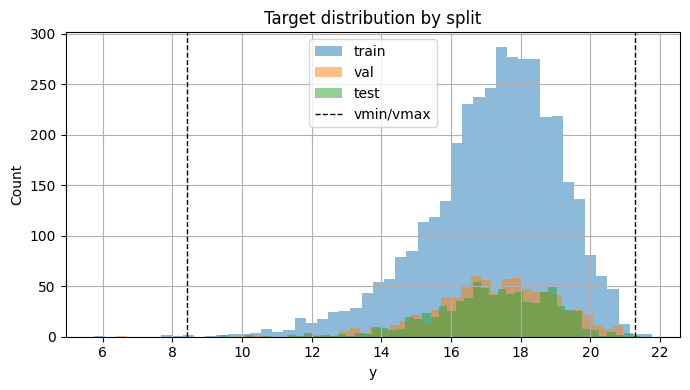

In [4]:
# Target range diagnostics + safe defaults
RANGE_PERCENTILES = (0.5, 99.5)
WIDEN_TEST_OUTSIDE_PCT = 0.5
FALLBACK_PERCENTILES = (0.1, 99.9)
FINAL_FALLBACK_PERCENTILES = (0.05, 99.95)


def pct_outside(y: np.ndarray, vmin: float, vmax: float) -> float:
    return float(np.mean((y < vmin) | (y > vmax)) * 100.0)


def summarize_range(y_train, y_val, y_test, vmin, vmax, label: str):
    print(f"{label} vmin={vmin:.4f}, vmax={vmax:.4f}")
    for name, arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
        print(
            f"  {name}: min={arr.min():.4f}, max={arr.max():.4f}, "
            f"pct_outside={pct_outside(arr, vmin, vmax):.3f}%"
        )


range_vmin, range_vmax = np.percentile(y_train_np, RANGE_PERCENTILES)
range_vmin = float(range_vmin)
range_vmax = float(range_vmax)

summarize_range(y_train_np, y_val_np, y_test_np, range_vmin, range_vmax, "Initial")

if pct_outside(y_test_np, range_vmin, range_vmax) > WIDEN_TEST_OUTSIDE_PCT:
    range_vmin, range_vmax = np.percentile(y_train_np, FALLBACK_PERCENTILES)
    range_vmin = float(range_vmin)
    range_vmax = float(range_vmax)
    summarize_range(y_train_np, y_val_np, y_test_np, range_vmin, range_vmax, "Widened")

if pct_outside(y_test_np, range_vmin, range_vmax) > WIDEN_TEST_OUTSIDE_PCT:
    range_vmin, range_vmax = np.percentile(y_train_np, FINAL_FALLBACK_PERCENTILES)
    range_vmin = float(range_vmin)
    range_vmax = float(range_vmax)
    summarize_range(y_train_np, y_val_np, y_test_np, range_vmin, range_vmax, "Final fallback")

plt.figure(figsize=(7, 4))
plt.hist(y_train_np, bins=50, alpha=0.5, label="train")
plt.hist(y_val_np, bins=50, alpha=0.5, label="val")
plt.hist(y_test_np, bins=50, alpha=0.5, label="test")
plt.axvline(range_vmin, color="k", linestyle="--", linewidth=1, label="vmin/vmax")
plt.axvline(range_vmax, color="k", linestyle="--", linewidth=1)
plt.xlabel("y")
plt.ylabel("Count")
plt.title("Target distribution by split")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Baseline Evaluation
Load the baseline checkpoint and compute test predictions/metrics for comparison.

In [5]:
from dataclasses import dataclass

# Legacy baseline checkpoints may reference these classes from __main__.
@dataclass
class EarlyStopConfig:
    patience: int = 25
    min_delta: float = 0.0
    restore_best: bool = True


@dataclass
class SchedConfig:
    enabled: bool = True
    mode: str = "min"
    factor: float = 0.5
    patience: int = 8
    min_lr: float = 1e-6
    threshold: float = 1e-4


baseline_model = TabularRegressor(
    mode=baseline_cfg["mode"],
    input_dim=int(baseline_cfg.get("input_dim", input_dim)),
    encoder_hidden=tuple(baseline_cfg.get("encoder_hidden", (256, 128, 64))),
    head_hidden=tuple(baseline_cfg.get("head_hidden", ())),
    dropout=float(baseline_cfg.get("dropout", 0.1)),
).to(device)

# Baseline checkpoint includes non-tensor metadata; allow full load for trusted local file.
ckpt = torch.load(baseline_model_path, map_location=device, weights_only=False)
baseline_model.load_state_dict(ckpt["model_state_dict"])
baseline_model.eval()

baseline_preds = []
baseline_true = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = baseline_model(xb).squeeze(-1)
        baseline_preds.append(pred.cpu().numpy())
        baseline_true.append(yb.cpu().numpy())

baseline_preds = np.concatenate(baseline_preds)
baseline_true = np.concatenate(baseline_true)

baseline_mse = float(np.mean((baseline_preds - baseline_true) ** 2))
baseline_mae = float(np.mean(np.abs(baseline_preds - baseline_true)))

baseline_pred_df = pd.DataFrame(
    {
        "name": test_df["name"].values,
        "y_true": baseline_true,
        "y_pred": baseline_preds,
        "residual": baseline_preds - baseline_true,
    }
)

print(f"Baseline test MSE: {baseline_mse:.4f} | MAE: {baseline_mae:.4f}")

Baseline test MSE: 1.0078 | MAE: 0.6981


## HL-Gauss Helpers
Utility functions for binning, expectation, and evaluation.

In [6]:
def build_bin_centers(
    y_train: np.ndarray,
    num_bins: int = 101,
    vmin: float = None,
    vmax: float = None,
    percentiles=(0.5, 99.5),
):
    if vmin is None or vmax is None:
        vmin, vmax = np.percentile(y_train, percentiles)
    centers = np.linspace(vmin, vmax, num_bins)
    return centers.astype(np.float32), float(vmin), float(vmax)


def expected_from_logits(logits: torch.Tensor, bin_centers: torch.Tensor) -> torch.Tensor:
    probs = torch.softmax(logits, dim=1)
    return (probs * bin_centers.unsqueeze(0)).sum(dim=1)


def evaluate_hl_gauss(model, loader, bin_centers_np: np.ndarray, device: torch.device):
    model.eval()
    bin_centers = torch.as_tensor(bin_centers_np, device=device, dtype=torch.float32)
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            pred = expected_from_logits(logits, bin_centers)
            preds.append(pred.cpu().numpy())
            trues.append(yb.cpu().numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mse = float(np.mean((preds - trues) ** 2))
    mae = float(np.mean(np.abs(preds - trues)))
    return preds, trues, mse, mae

## HL-Gauss Hyperparameter Sweep
Quick sweep over bin count and sigma ratio; choose best by validation MSE.

In [7]:
num_bins_list = [51, 101]
sigma_ratio_list = [0.5, 0.75, 1.0]

sweep_rows = []
best_cfg = None
best_history = None
best_val_mse = float("inf")
best_bin_centers = None
best_vmin = None
best_vmax = None

for num_bins in num_bins_list:
    for sigma_ratio in sigma_ratio_list:
        bin_centers, vmin, vmax = build_bin_centers(
            y_train_np,
            num_bins=num_bins,
            vmin=range_vmin,
            vmax=range_vmax,
        )
        cfg = TrainConfig(
            mode=baseline_cfg.get("mode", "shared"),
            input_dim=input_dim,
            encoder_hidden=tuple(baseline_cfg.get("encoder_hidden", (256, 128, 64))),
            head_hidden=tuple(baseline_cfg.get("head_hidden", ())),
            dropout=float(baseline_cfg.get("dropout", 0.1)),
            lr=float(baseline_cfg.get("lr", 1e-3)),
            epochs=int(baseline_cfg.get("epochs", 200)),
            batch_size=batch_size,
            device=str(device),
        )
        cfg.loss_type = "hl_gauss"
        cfg.num_bins = num_bins
        cfg.sigma_ratio = sigma_ratio
        cfg.bin_centers = bin_centers
        cfg.monitor = "val_mse"
        cfg.monitor_mode = "min"

        print(f"Sweep: bins={num_bins}, sigma_ratio={sigma_ratio}")
        set_seed(0)
        model_tmp, history_tmp = train_model(cfg, train_loader, val_loader, X_is_separate=False)

        val_mse = float(np.min(history_tmp["val_mse"]))
        best_epoch = int(np.argmin(history_tmp["val_mse"]) + 1)
        sweep_rows.append(
            {
                "num_bins": num_bins,
                "sigma_ratio": sigma_ratio,
                "best_val_mse": val_mse,
                "best_epoch": best_epoch,
                "vmin": float(vmin),
                "vmax": float(vmax),
            }
        )

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_cfg = cfg
            best_history = history_tmp
            best_bin_centers = bin_centers
            best_vmin = vmin
            best_vmax = vmax

        del model_tmp
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

sweep_df = pd.DataFrame(sweep_rows).sort_values("best_val_mse").reset_index(drop=True)
display(sweep_df)
print("Best sweep config:", sweep_df.iloc[0].to_dict())

Sweep: bins=51, sigma_ratio=0.5


Epoch 001 | train loss 3.5127 | val loss 2.9525 | train MSE 4.5598 | val MSE 1.4914 | train MAE 1.6806 | val MAE 0.8911
Epoch 010 | train loss 2.5645 | val loss 2.6512 | train MSE 1.0163 | val MSE 1.2763 | train MAE 0.6993 | val MAE 0.7897
Epoch 020 | train loss 2.4824 | val loss 2.6420 | train MSE 0.9226 | val MSE 1.1442 | train MAE 0.6606 | val MAE 0.7484
Epoch 030 | train loss 2.4126 | val loss 2.6813 | train MSE 0.8433 | val MSE 1.2201 | train MAE 0.6263 | val MAE 0.7983
Epoch 040 | train loss 2.3507 | val loss 2.7595 | train MSE 0.7776 | val MSE 1.2369 | train MAE 0.5999 | val MAE 0.8277
Epoch 050 | train loss 2.2730 | val loss 2.7712 | train MSE 0.7092 | val MSE 1.0894 | train MAE 0.5661 | val MAE 0.7479
Epoch 060 | train loss 2.1674 | val loss 2.9350 | train MSE 0.6261 | val MSE 1.1624 | train MAE 0.5252 | val MAE 0.7757
Epoch 070 | train loss 2.0879 | val loss 3.0163 | train MSE 0.6045 | val MSE 1.1322 | train MAE 0.4949 | val MAE 0.7779
Epoch 080 | train loss 1.9894 | val loss

,num_bins,sigma_ratio,best_val_mse,best_epoch,vmin,vmax
0,101,1.00,1.029841,44,8.426445,21.276669
1,51,0.75,1.035877,38,8.426445,21.276669
2,51,0.50,1.039945,38,8.426445,21.276669
3,51,1.00,1.066295,38,8.426445,21.276669
4,101,0.75,1.071920,29,8.426445,21.276669
5,101,0.50,1.104128,29,8.426445,21.276669


Best sweep config: {'num_bins': 101.0, 'sigma_ratio': 1.0, 'best_val_mse': 1.0298410207033157, 'best_epoch': 44.0, 'vmin': 8.42644461774826, 'vmax': 21.276669464111446}


## Train Final HL-Gauss Model
Train the best sweep configuration end-to-end for evaluation.

In [8]:
if best_cfg is None:
    raise RuntimeError("Sweep did not produce a valid configuration")

best_cfg.monitor = "val_mse"
best_cfg.monitor_mode = "min"

print("Training final HL-Gauss model...")
set_seed(0)
model_hl, history_hl = train_model(best_cfg, train_loader, val_loader, X_is_separate=False)
model_hl = model_hl.to(device).eval()

hl_best_epoch = int(getattr(model_hl, "best_epoch", np.argmin(history_hl["val_mse"]) + 1))
hl_best_val_mse = float(np.min(history_hl["val_mse"]))

print(f"Final HL-Gauss best val MSE: {hl_best_val_mse:.4f} at epoch {hl_best_epoch}")


Training final HL-Gauss model...
Epoch 001 | train loss 4.2478 | val loss 3.7488 | train MSE 4.7186 | val MSE 1.6139 | train MAE 1.7214 | val MAE 0.9024
Epoch 010 | train loss 3.2684 | val loss 3.3499 | train MSE 1.0299 | val MSE 1.1677 | train MAE 0.7015 | val MAE 0.7825
Epoch 020 | train loss 3.1986 | val loss 3.3577 | train MSE 0.9562 | val MSE 1.2146 | train MAE 0.6785 | val MAE 0.7913
Epoch 030 | train loss 3.1228 | val loss 3.3664 | train MSE 0.8770 | val MSE 1.1707 | train MAE 0.6389 | val MAE 0.7715
Epoch 040 | train loss 3.0688 | val loss 3.4007 | train MSE 0.8306 | val MSE 1.1522 | train MAE 0.6110 | val MAE 0.7895
Epoch 050 | train loss 2.9677 | val loss 3.5124 | train MSE 0.7260 | val MSE 1.2857 | train MAE 0.5632 | val MAE 0.8377
Epoch 060 | train loss 2.9031 | val loss 3.5981 | train MSE 0.6581 | val MSE 1.1994 | train MAE 0.5344 | val MAE 0.8029
Epoch 070 | train loss 2.8231 | val loss 3.7409 | train MSE 0.5951 | val MSE 1.3817 | train MAE 0.5015 | val MAE 0.8338
Epoch 0

## HL-Gauss Test Evaluation
Compute scalar predictions from logits and report test MSE/MAE.

In [9]:
hl_preds, hl_true, hl_mse, hl_mae = evaluate_hl_gauss(
    model_hl, test_loader, best_bin_centers, device
)

hl_pred_df = pd.DataFrame(
    {
        "name": test_df["name"].values,
        "y_true": hl_true,
        "y_pred": hl_preds,
        "residual": hl_preds - hl_true,
    }
)

print(f"HL-Gauss test MSE: {hl_mse:.4f} | MAE: {hl_mae:.4f}")

bin_width = (best_vmax - best_vmin) / max(int(best_cfg.num_bins) - 1, 1)
near_min = np.mean(hl_preds <= (best_vmin + bin_width)) * 100.0
near_max = np.mean(hl_preds >= (best_vmax - bin_width)) * 100.0
sat_pct = near_min + near_max
print(
    f"HL-Gauss saturation near edges: {sat_pct:.2f}% "
    f"(near vmin: {near_min:.2f}%, near vmax: {near_max:.2f}%)"
)
if sat_pct > 2.0:
    print("WARNING: High edge saturation in HL-Gauss predictions.")

HL-Gauss test MSE: 1.0053 | MAE: 0.6974
HL-Gauss saturation near edges: 0.00% (near vmin: 0.00%, near vmax: 0.00%)


## Save Artifacts
Persist model checkpoint, training history, metrics, predictions, and config.

In [10]:
model_path = CHECKPOINT_DIR / "hl_gauss_regressor.pt"

# Save a pickle-safe config to avoid custom class issues on load.

def _to_serializable(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, (list, tuple)):
        return [_to_serializable(v) for v in value]
    if isinstance(value, dict):
        return {k: _to_serializable(v) for k, v in value.items()}
    return value

config_safe = _to_serializable(best_cfg.__dict__)

save_payload = {
    "model_state_dict": model_hl.state_dict(),
    "config": config_safe,
    "input_dim": int(input_dim),
    "bin_centers": _to_serializable(best_bin_centers),
    "vmin": float(best_vmin),
    "vmax": float(best_vmax),
    "sigma_ratio": float(best_cfg.sigma_ratio),
}

torch.save(save_payload, model_path)
print(f"Saved model to {model_path}")

history_path = RESULTS_DIR / "training_history.csv"
pd.DataFrame(history_hl).to_csv(history_path, index=False)
print(f"Saved training history to {history_path}")

best_epoch_path = RESULTS_DIR / "best_epoch.json"
with best_epoch_path.open("w") as f:
    json.dump(
        {
            "epoch": int(hl_best_epoch),
            "val_mse": float(hl_best_val_mse),
            "monitor": "val_mse",
        },
        f,
        indent=2,
    )
print(f"Saved best epoch info to {best_epoch_path}")

metrics_path = RESULTS_DIR / "test_metrics.csv"
metrics_df = pd.DataFrame(
    [
        {"model": "baseline_mse", "test_mse": baseline_mse, "test_mae": baseline_mae},
        {"model": "hl_gauss", "test_mse": hl_mse, "test_mae": hl_mae},
    ]
)
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved test metrics to {metrics_path}")

preds_path = RESULTS_DIR / "sample_predictions.csv"
hl_pred_df.to_csv(preds_path, index=False)
print(f"Saved sample predictions to {preds_path}")

config_path = CONFIG_SNAPSHOT_PATH
with config_path.open("w") as f:
    json.dump(
        {
            **config_safe,
            "artifact_root": str(ARTIFACT_ROOT),
            "vmin": float(best_vmin),
            "vmax": float(best_vmax),
            "num_bins": int(best_cfg.num_bins),
            "sigma_ratio": float(best_cfg.sigma_ratio),
            "best_epoch": int(hl_best_epoch),
            "best_val_mse": float(hl_best_val_mse),
            "monitor": "val_mse",
        },
        f,
        indent=2,
    )
print(f"Saved config to {config_path}")

Saved model to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\checkpoints\hl_gauss_regressor.pt
Saved training history to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\results\training_history.csv
Saved best epoch info to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\results\best_epoch.json
Saved test metrics to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\results\test_metrics.csv
Saved sample predictions to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\results\sample_predictions.csv
Saved config to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\results\config.json


## Plots and Comparison
Generate training curves, loss curves, prediction quality plots, and metric comparisons.

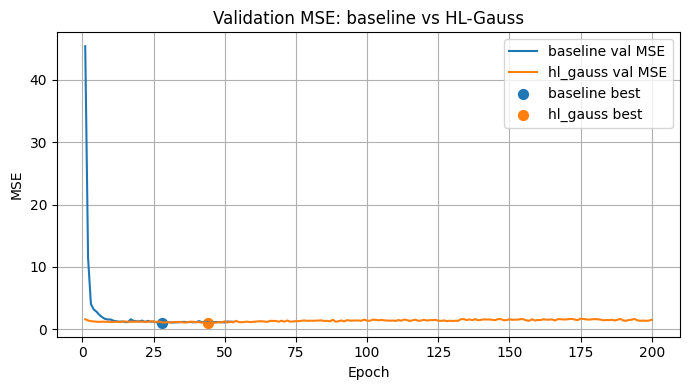

Saved val MSE plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\plots\val_mse_compare.png


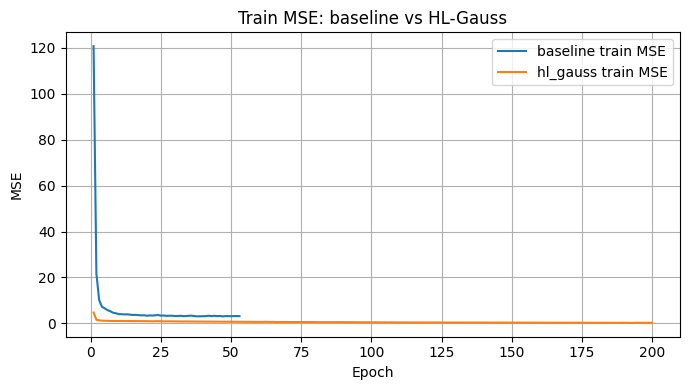

Saved train MSE plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\plots\train_mse_compare.png


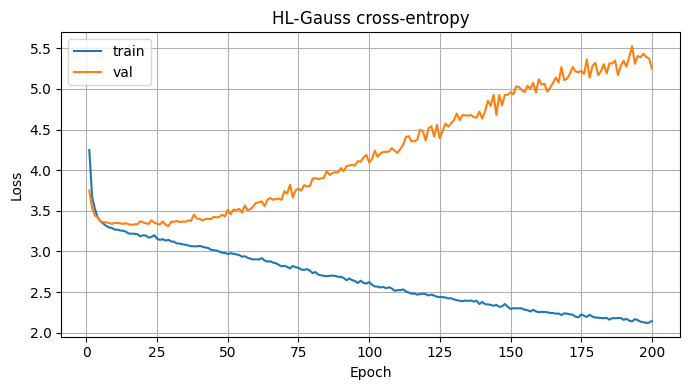

Saved HL-Gauss CE loss plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\plots\hl_gauss_ce_loss.png


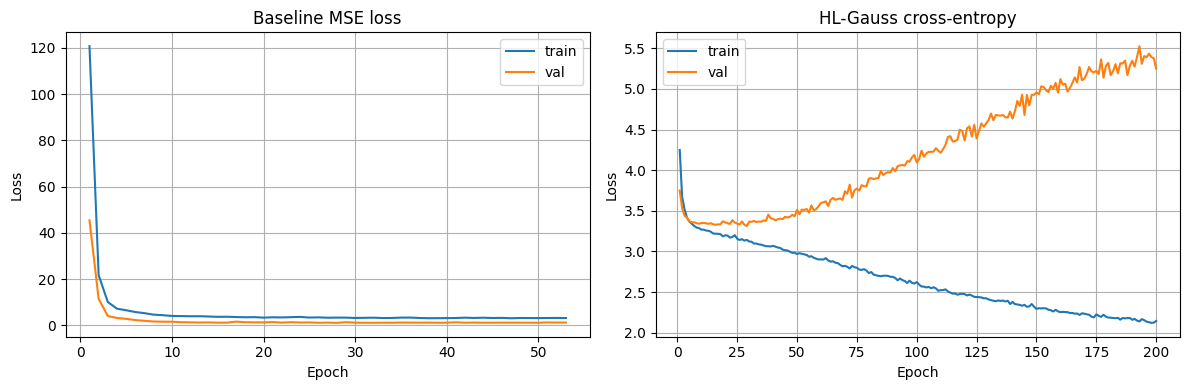

Saved loss curves to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\plots\loss_curves.png


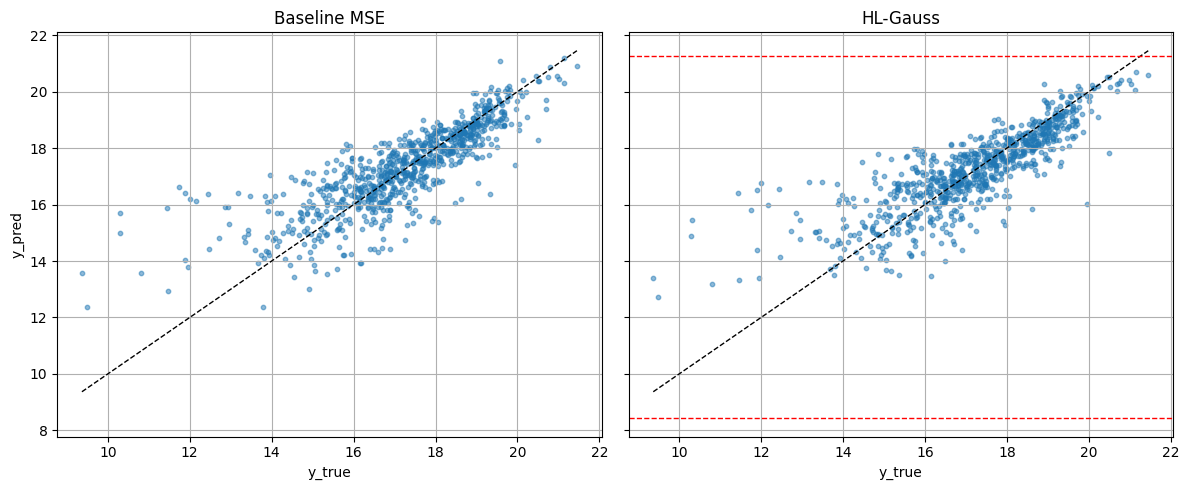

Saved scatter plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\plots\pred_scatter_compare.png


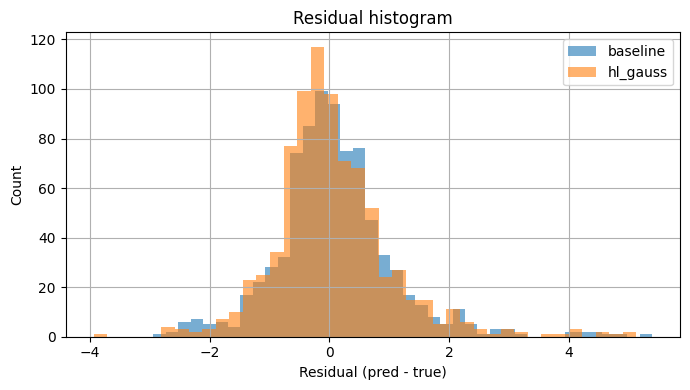

Saved residual histogram to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\plots\residual_hist_compare.png


,model,test_mse,test_mae
0,baseline_mse,1.0078,0.6981
1,hl_gauss,1.0053,0.6974


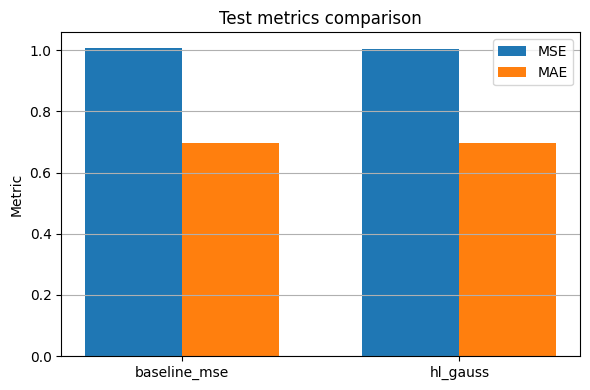

Saved metrics plot to c:\Users\ydreizin\OneDrive - NVIDIA Corporation\Documents\Technion\RateAhead\notebooks\artifacts\hl_gauss\plots\test_metrics_compare.png


In [11]:
# 1) Training curves overlay (MSE)
plt.figure(figsize=(7, 4))
plt.plot(baseline_history["val_loss"], label="baseline val MSE")
plt.plot(history_hl["val_mse"], label="hl_gauss val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Validation MSE: baseline vs HL-Gauss")
plt.legend()
plt.grid(True)
plt.tight_layout()
val_mse_plot_path = PLOTS_DIR / "val_mse_compare.png"
plt.savefig(val_mse_plot_path, dpi=150)
plt.show()
print(f"Saved val MSE plot to {val_mse_plot_path}")

plt.figure(figsize=(7, 4))
plt.plot(baseline_history["train_loss"], label="baseline train MSE")
plt.plot(history_hl["train_mse"], label="hl_gauss train MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Train MSE: baseline vs HL-Gauss")
plt.legend()
plt.grid(True)
plt.tight_layout()
train_mse_plot_path = PLOTS_DIR / "train_mse_compare.png"
plt.savefig(train_mse_plot_path, dpi=150)
plt.show()
print(f"Saved train MSE plot to {train_mse_plot_path}")

# 2) Loss curves (baseline MSE vs HL-Gauss cross-entropy)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(baseline_history["train_loss"], label="train")
axes[0].plot(baseline_history["val_loss"], label="val")
axes[0].set_title("Baseline MSE loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_hl["train_loss"], label="train")
axes[1].plot(history_hl["val_loss"], label="val")
axes[1].set_title("HL-Gauss cross-entropy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
loss_plot_path = PLOTS_DIR / "loss_curves.png"
plt.savefig(loss_plot_path, dpi=150)
plt.show()
print(f"Saved loss curves to {loss_plot_path}")

# 3) Prediction quality plots
plt.figure(figsize=(6, 6))
plt.scatter(baseline_true, baseline_preds, alpha=0.5, label="baseline", s=10)
plt.scatter(hl_true, hl_preds, alpha=0.5, label="hl_gauss", s=10)
lims = [
    min(baseline_true.min(), hl_true.min()),
    max(baseline_true.max(), hl_true.max()),
]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("y_true")
plt.ylabel("y_pred")
plt.title("Test predictions: baseline vs HL-Gauss")
plt.legend()
plt.grid(True)
plt.tight_layout()
scatter_path = PLOTS_DIR / "pred_scatter_compare.png"
plt.savefig(scatter_path, dpi=150)
plt.show()
print(f"Saved scatter plot to {scatter_path}")

plt.figure(figsize=(7, 4))
plt.hist(baseline_preds - baseline_true, bins=40, alpha=0.6, label="baseline")
plt.hist(hl_preds - hl_true, bins=40, alpha=0.6, label="hl_gauss")
plt.xlabel("Residual (pred - true)")
plt.ylabel("Count")
plt.title("Residual histogram")
plt.legend()
plt.grid(True)
plt.tight_layout()
resid_path = PLOTS_DIR / "residual_hist_compare.png"
plt.savefig(resid_path, dpi=150)
plt.show()
print(f"Saved residual histogram to {resid_path}")

# 4) Metrics summary table + bar plot
with pd.option_context("display.float_format", "{:.4f}".format):
    display(metrics_df)

plt.figure(figsize=(6, 4))
bar_x = np.arange(len(metrics_df))
bar_width = 0.35
plt.bar(bar_x - bar_width / 2, metrics_df["test_mse"], bar_width, label="MSE")
plt.bar(bar_x + bar_width / 2, metrics_df["test_mae"], bar_width, label="MAE")
plt.xticks(bar_x, metrics_df["model"], rotation=0)
plt.ylabel("Metric")
plt.title("Test metrics comparison")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
metrics_plot_path = PLOTS_DIR / "test_metrics_compare.png"
plt.savefig(metrics_plot_path, dpi=150)
plt.show()
print(f"Saved metrics plot to {metrics_plot_path}")